In [1]:
import numpy as np
import pandas as pd
import random
import time
from rapidfuzz import process, fuzz, distance
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import spoa 
from sklearn.metrics.pairwise import pairwise_distances
from sklearn.cluster import HDBSCAN
import statistics
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN

# --- 2. DATA GENERATION & UTILS ---
def mutate_sequence(seq, error_rate=0.10):
    if error_rate <= 0: return seq
    seq_list = list(seq)
    new_seq = []
    for base in seq_list:
        if random.random() < error_rate:
            r = random.random()
            if r < 0.5: new_seq.append(random.choice("ACGT")) 
            elif r < 0.75: 
                new_seq.append(base)
                new_seq.append(random.choice("ACGT"))
            else: pass 
        else:
            new_seq.append(base)
    return "".join(new_seq)

def gen_dna(k): return "".join(random.choices("ACGT", k=k))

# (Generating fresh data to ensure variables exist for the loop below)
n_items = 20_000 
pool_bc = [gen_dna(12) for _ in range(n_items)]
pool_ins = [gen_dna(40) for _ in range(n_items)]
n_repeat_bc = 500
pool_bc += pool_bc[0:n_repeat_bc]
pool_ins += [gen_dna(50) for _ in range(n_repeat_bc)]
pool_bc += pool_bc[0:n_repeat_bc]
pool_ins += [gen_dna(50) for _ in range(n_repeat_bc)]

data = []
for i in range(len(pool_bc)):
     n_reads = random.randint(3, 6) 
     for _ in range(n_reads):
         data.append({
             "ID": i,
             "Barcode": mutate_sequence(pool_bc[i], 0.1), 
             "Insert": mutate_sequence(pool_ins[i], 0.1)
         })

df = pd.DataFrame(data)

In [92]:
from scipy.stats import mode

def encode_msa(msa_strings, alphabet="ACGTN-"):
    char_to_int = {c: i for i, c in enumerate(alphabet)}
    max_len = max(len(s) for s in msa_strings)
    msa_padded = [s.ljust(max_len, '-') for s in msa_strings]
    msa_array = np.array([list(seq) for seq in msa_padded])
    N, L = msa_array.shape
    msa_int = np.zeros((N, L), dtype=np.int8)
    for char, idx in char_to_int.items():
        msa_int[msa_array == char] = idx
    return msa_int, len(alphabet)


def get_marginals(msa_int, vocab_size):
    # Create on hot matrix
    one_hot = np.eye(vocab_size)[msa_int]
    # Calculate frequencies of each base/N/- at each position in MSA
    P_i = one_hot.mean(axis=0)
    return one_hot, P_i

def compute_mi_scores(one_hot, P_i):
    """
    Compute mutual information scores in the MSA
    """
    N, L, A = one_hot.shape
    flat_view = one_hot.transpose(1, 2, 0).reshape(L * A, N)
    joint_probs_flat = (flat_view @ flat_view.T) / N
    P_ij = joint_probs_flat.reshape(L, A, L, A)
    P_product = P_i[:, :, None, None] * P_i[None, None, :, :]
    mask = P_ij > 0
    mi_matrix = np.zeros_like(P_ij)
    mi_matrix[mask] = P_ij[mask] * np.log(P_ij[mask] / P_product[mask])
    return mi_matrix.sum(axis=(1, 3))


def get_elbow_columns(mi_matrix, exclusion_distance=5, verbose=0):
    L = mi_matrix.shape[0]
    mask = np.triu(np.ones((L, L), dtype=bool), k=exclusion_distance + 1)
    rows, cols = np.where(mask)
    scores = mi_matrix[rows, cols]
    
    if len(scores) == 0: return np.array([])

    # 1. Sort Descending
    sorted_indices = np.argsort(scores)[::-1]
    sorted_scores = scores[sorted_indices]
    
    # 2. Determine "Signal End" (Noise Floor Truncation)
    # We stop analyzing where the score drops below the bottom 25% percentile
    noise_floor = np.percentile(scores, 25)
    
    # Keep points strictly ABOVE noise floor for the shape analysis
    # (But keep at least 5 points to allow for geometry, unless total is small)
    valid_mask = sorted_scores > noise_floor
    n_signal_points = np.sum(valid_mask)
    
    # Safety: if signal is super short, take at least top 10% or min 5
    min_points = min(len(sorted_scores), 5)
    cutoff_idx = max(n_signal_points, min_points)
    
    # 3. Truncate for Geometry Calculation
    # We only look for the elbow within the "Signal" region
    curve_y = sorted_scores[:cutoff_idx]
    n_points = len(curve_y)
    
    if n_points < 3:
        # Fallback for tiny signals
        return np.unique(np.concatenate([rows[sorted_indices[:n_points]], cols[sorted_indices[:n_points]]]))

    # 4. Standard Kneedle on Truncated Curve
    x_norm = np.linspace(0, 1, n_points)
    y_norm = (curve_y - curve_y.min()) / (curve_y.max() - curve_y.min() + 1e-9)
    
    # Line from First Point (0, 1) to Last Signal Point (1, 0)
    line_vec = np.array([1.0, -1.0]) # Direction vector (x=1-0, y=0-1)
    line_vec = line_vec / np.linalg.norm(line_vec)
    
    # Vectors from start (0, 1) to all points
    vec_from_start = np.stack([x_norm, y_norm - 1.0], axis=1)
    
    # Cross product (2D) to find distance
    distances = np.abs(vec_from_start[:, 0] * line_vec[1] - vec_from_start[:, 1] * line_vec[0])
    
    # 5. Select
    elbow_idx = np.argmax(distances)
    
    # If the plateau is perfectly flat, elbow_idx might be 0. 
    # In that case, we likely want the whole plateau, not just index 0.
    # We check if the point at elbow_idx is significantly higher than end.
    if elbow_idx == 0:
        # Heuristic: If index 0 is picked, but index 1 is very close in value, walk forward
        # This handles the "perfect plateau" case
        for i in range(1, n_points - 1):
            if curve_y[i] >= (curve_y[0] * 0.95): # Still within 5% of max
                elbow_idx = i
            else:
                break

    n_selected = elbow_idx + 1 # +1 because index is 0-based
    
    # --- Debug Plot (Only if Verbose) ---
    if verbose >= 3:
        import matplotlib.pyplot as plt
        plt.figure(figsize=(6, 3))
        plt.plot(range(n_points), curve_y, '-o', markersize=3, label='Signal Curve')
        plt.axvline(elbow_idx, color='r', linestyle='--', label=f'Elbow (k={n_selected})')
        plt.axhline(noise_floor, color='k', linestyle=':', alpha=0.5, label='Noise Floor')
        plt.title(f"Elbow Analysis (Selecting {n_selected} cols)")
        plt.legend()
        plt.show()

    selected_indices = sorted_indices[:n_selected]

    selected_columns = np.unique(np.concatenate([rows[selected_indices], cols[selected_indices]]))
    
    if verbose >= 3:
        print(f"selected MSA columns: {selected_columns}")
    return selected_columns


def calculate_msa_mi_and_top_cols(barcodes, inserts, verbose=0, mi_exclusion_distance=3):
    
    _, msa_barcodes = spoa.poa(barcodes, algorithm=2) 
    _, msa_inserts = spoa.poa(inserts, algorithm=2)
    msa_strings = [b + "-"*10 + i for b, i in zip(msa_barcodes, msa_inserts)]

    len_msa_inserts = len(msa_inserts[0])  # store for later checks

    # Encode MSA into a numpy array with numbers (should be treated as categoricals)
    msa_int, vocab_size = encode_msa(msa_strings)

    # Create one hot matrix and the frequencies of each base at each position in MSA
    one_hot, P_i = get_marginals(msa_int, vocab_size)
    
    # Calculate mutual information scores in MSA
    mi_matrix = compute_mi_scores(one_hot, P_i)

    # Use elbow approach to find pairs in MSA with high mutual information
    # Exclude very close positions as sequencing errors of more than one base may 
    # produce spurious mutual info
    top_cols = get_elbow_columns(mi_matrix, mi_exclusion_distance, verbose=verbose)   

    return msa_int, mi_matrix, top_cols, len_msa_inserts



def cluster_msa_subset_with_HDBSCAN(msa_subset, expected_error_rate, never_link=3):
    # Compute Hamming distance matrix
    dist_matrix_subset = pairwise_distances(msa_subset, metric='hamming')

    if dist_matrix_subset.shape[0] == 1:
        return dist_matrix_subset, np.array([0])  # only one
    elif dist_matrix_subset.shape[0] == 2:
        return dist_matrix_subset, np.array([0, 1])  # just split in 2

  

    if PLOTS:
        # --- 1. Heatmap ---
        plt.figure(figsize=(8, 7))
        sns.heatmap(
            dist_matrix_subset,
            annot=True,
            cmap="viridis",
            fmt=".2f",
            linewidths=.5,
            cbar_kws={'label': 'Hamming Distance'}
        )
        plt.title('Heatmap of Distance Matrix Subset', fontsize=14)
        plt.ylabel('Row Sample', fontsize=12)
        plt.xlabel('Column Sample', fontsize=12)
        plt.tight_layout()
        plt.show()

        # --- 2. MDS Plot ---
        # Initialize MDS
        # dissimilarity='precomputed' is CRITICAL here because we are passing a distance matrix
        
        plt.figure(figsize=(8, 7))

        mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42, normalized_stress='auto')

        mds_coords = mds.fit_transform(dist_matrix_subset)
        
        # Plot the scatter
        # If you have 'labels' defined at this stage, you can use c=labels to color by cluster
        plt.scatter(mds_coords[:, 0], mds_coords[:, 1], s=100, alpha=0.7, c='royalblue', edgecolors='k')
        
        # Annotate points with their index (optional, helps identify outliers)
        for i, (x, y) in enumerate(mds_coords):
            plt.text(x, y, str(i), fontsize=9, ha='right', va='bottom')

        plt.title('MDS of MSA Subset (Hamming Distance)', fontsize=14)
        plt.xlabel('MDS Dimension 1', fontsize=12)
        plt.ylabel('MDS Dimension 2', fontsize=12)
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()

        from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
        from scipy.spatial.distance import squareform
        
        # 1. Convert square distance matrix to condensed form (required for linkage)
        condensed_dist = squareform(dist_matrix_subset)
        
        # 2. Compute the linkage (Ward's method is usually best for "tight" clusters)
        Z = linkage(condensed_dist, method='single')
        
        # 3. Plot Dendrogram to see the structure
        plt.figure(figsize=(10, 5))
        plt.title('Hierarchical Clustering Dendrogram')
        dendrogram(Z)
        plt.xlabel('Sample Index')
        plt.ylabel('Distance')
        plt.show()
        
        # 4. "Cut" the tree to get labels
        # t=distance_threshold. You can look at the Y-axis of the dendrogram to pick this cut.
        # Alternatively, specify 'maxclust' to force k groups.
        labels_hierarchical = fcluster(Z, t=2, criterion='maxclust') # e.g. force 2 clusters
        
        # Adjust labels to be 0-indexed to match your pipeline format
        labels = labels_hierarchical - 1

        print(labels)

        mean_dists = np.mean(dist_matrix_subset, axis=1)
        
        # 2. Find the Elbow (The Largest Gap)
        # Sort the distances to visualize the curve
        sorted_indices = np.argsort(mean_dists)
        sorted_vals = mean_dists[sorted_indices]
        
        # Calculate the difference between consecutive points
        jumps = np.diff(sorted_vals)
        
        # The "Elbow" is simply the index where the biggest jump occurs
        elbow_idx = np.argmax(jumps)
        threshold = (sorted_vals[elbow_idx] + sorted_vals[elbow_idx + 1]) / 2
        
        # 3. Assign Labels
        # 0 = Main Cluster, 1 = Outlier
        labels = (mean_dists > threshold).astype(int)

        plt.figure(figsize=(8, 5))
        plt.plot(range(len(sorted_vals)), sorted_vals, 'o-', markersize=4, label='Mean Distances')
        
        # Visualize the cut
        plt.axhline(y=threshold, color='r', linestyle='--', label=f'Cutoff: {threshold:.2f}')
        plt.axvline(x=elbow_idx + 0.5, color='gray', linestyle=':', alpha=0.5)
        
        plt.title('Elbow Detection (Largest Gap Method)', fontsize=14)
        plt.ylabel('Mean Distance to Peers')
        plt.xlabel('Sample Index (Sorted)')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

        print(f"Split found at {threshold:.4f}. Detected {np.sum(labels)} outliers.")


    # --- Primary method: HDBSCAN ---
    # hdb = HDBSCAN(
    #     metric='precomputed',
    #     min_cluster_size=2,
    #     min_samples=1,
    #     cluster_selection_method='leaf',
    #     copy=True
    # )

    # labels = hdb.fit_predict(dist_matrix_subset)

    # opt = OPTICS(
    # metric='precomputed',
    # min_samples=2,          # analogous to HDBSCAN's min_samples
    # min_cluster_size=2,     # analogous to HDBSCAN's min_cluster_size
    # xi=0.05,                # controls cluster extraction sensitivity
    # cluster_method='xi'     # enables automatic cluster selection
    # )

    # labels = opt.fit_predict(dist_matrix_subset)

    # condensed = squareform(dist_matrix_subset, checks=False)

    # Z = linkage(condensed, method='complete')

    # # compute merge distances
    # dists = Z[:, 2]
    
    # # find biggest jump
    # k = np.argmax(np.diff(dists)) + 1
    
    # labels = fcluster(Z, k, criterion='maxclust')

    # build similarity (affinity) matrix from distance; ensure non-negative
    # aff = 1.0 - dist_matrix_subset  # if your distances are in [0,1]
    # np.fill_diagonal(aff, 1.0)
    
    # # compute normalized Laplacian eigenvalues
    # D = np.diag(aff.sum(axis=1))
    # L = D - aff
    # # for generalized eigenproblem (Lx = lambda D x) use eigh
    # eigvals, eigvecs = eigh(L, D)   # sorted ascending
    
    # # compute eigengaps
    # gaps = np.diff(eigvals)
    # best_k = np.argmax(gaps) + 1
    # print("eigengaps:", gaps[:10], "=> suggested k:", best_k)
    
    # cl = SpectralClustering(n_clusters=best_k, affinity='precomputed', assign_labels='kmeans')
    # labels = cl.fit_predict(aff)


    smooth=5
    jump_factor=1.5
    Z = linkage(squareform(dist_matrix_subset, checks=False), method='average')
    order = leaves_list(Z)
    D = dist_matrix_subset[order][:, order]

    # 2. Compute local average dissimilarity along diagonal
    n = D.shape[0]
    diag_profile = np.array([
        D[i, max(0, i-smooth):i+smooth+1].mean()
        for i in range(n)
    ])

    # 3. Look for sudden jumps along diagonal
    diffs = np.diff(diag_profile)

    # threshold = multiple of median diff
    thresh = np.median(np.abs(diffs)) * jump_factor

    boundaries = np.where(np.abs(diffs) > thresh)[0] + 1
    boundaries = [0] + boundaries.tolist() + [n]

    # 4. Convert continuous blocks into labels
    labels = np.zeros(n, dtype=int)
    for c, (s, e) in enumerate(zip(boundaries[:-1], boundaries[1:])):
        labels[s:e] = c

    # undo reordering
    inv = np.argsort(order)
    labels = labels[inv]

    unique_labels = list(set(labels))

    
    if (len(unique_labels) == 1 and unique_labels[0] == -1) or len(unique_labels) == 1:  # then HDBSCAN just found noise
        # # --- Fallback: Spectral Clustering ---
        # # Use similarity matrix (Spectral needs affinities, not distances)
        # sim_matrix = 1.0 - dist_matrix_subset

        # # Decide number of clusters:
        # # If HDBSCAN found none: guess based on silhouette-like heuristic
        # # Minimum: 2 clusters
        # # n_clusters = max(2, min(msa_subset.shape[0] // 2, 5))
        # n_clusters = 2

        # spectral = SpectralClustering(
        #     affinity='precomputed',
        #     n_clusters=n_clusters,
        #     assign_labels='discretize'
        # )

        # labels = spectral.fit_predict(sim_matrix)

        # if verbose >= 2:
        #     print("SPECTRAL")
        #     print(labels)

        mean_dists = np.mean(dist_matrix_subset, axis=1)

        # Sort the distances to visualize the curve
        sorted_indices = np.argsort(mean_dists)
        sorted_vals = mean_dists[sorted_indices]
        
        # Calculate the difference between consecutive points
        jumps = np.diff(sorted_vals)
        
        # The "Elbow" is simply the index where the biggest jump occurs
        elbow_idx = np.argmax(jumps)
        threshold = (sorted_vals[elbow_idx] + sorted_vals[elbow_idx + 1]) / 2

        labels = (mean_dists > threshold).astype(int)

        # TODO check if split is justified!
    # else:
    #     print("Using HDBSCAN")
    #     print(labels)

    return dist_matrix_subset, labels



def cluster_barcode_insert_pairs(barcodes, inserts, mi_exclusion_distance, expected_error_rate, verbose=0):
    
    # Produce integer-encoded msa, mutual information matrix and identify most informative columns
    msa_int, mi_matrix, top_cols, len_msa_inserts = calculate_msa_mi_and_top_cols(barcodes, inserts, verbose, mi_exclusion_distance)

    # Get just the most informative (i.e., highest mutual information) columns of MSA
    msa_subset = msa_int[:, top_cols]

    if PLOTS:
        # Set up the figure size
        plt.figure(figsize=(10, 4)) 
        
        # Use a specific color map (e.g., 'magma', 'viridis', or a custom one)
        sns.heatmap(
            msa_subset,
            cmap="viridis",  
            cbar=True,         # Show the color bar
            yticklabels=False, # Hide individual sequence labels if you have many
            xticklabels=10     # Show tick labels every 10 positions
        )
        
        plt.title("Heatmap of Integer Encoded MSA", fontsize=14)
        plt.ylabel("Sequence Index", fontsize=12)
        plt.xlabel("Position in Alignment", fontsize=12)
        plt.show()

    # Identify rough clusters using HDBSCAN
    dist_matrix_subset, labels = cluster_msa_subset_with_HDBSCAN(msa_subset, expected_error_rate)

    return msa_int, mi_matrix, msa_subset, dist_matrix_subset, labels, len_msa_inserts


def plot_confusion_matrix(labels, real_IDs):
    from sklearn.metrics.cluster import contingency_matrix
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np
    
    # 1. Compute the contingency matrix
    # This counts the overlap between every unique value in labels vs real_IDs
    cont_mat = contingency_matrix(labels, real_IDs)
    
    # 2. Visualize
    plt.figure(figsize=(10, 8))
    sns.heatmap(cont_mat, annot=True, fmt='d', cmap="Blues")
    plt.xlabel("Real IDs (Arbitrary)")
    plt.ylabel("Predicted Labels (Arbitrary)")
    plt.title("Contingency Matrix (Unsorted)")
    plt.show()
    


import numpy as np
from scipy.stats import mode

import numpy as np

def fast_consensus(msa_list, threshold=0.5):
    """
    Rapid consensus that handles ties by lowercasing the winner.
    Uses int8 views for maximum speed and robustness.
    """
    if not msa_list:
        return ""

    # 1. Convert to BYTES (S1) and then VIEW as Integers (int8)
    # This is the key to speed: we work with numbers (ASCII codes), not strings.
    # 'A' is 65, 'a' is 97, '-' is 45.
    arr = np.array([list(s) for s in msa_list], dtype='S1')
    arr_int = arr.view(np.int8)
    
    n_seqs, length = arr_int.shape
    consensus_int = []
    
    # Constants for checks
    GAP_ASCII = 45 # '-'
    TO_LOWER_OFFSET = 32 # Add this to Uppercase ASCII to get Lowercase
    
    # 2. Iterate columns (Positions)
    # Using np.unique on int8 is extremely fast (much faster than strings)
    for i in range(length):
        col = arr_int[:, i]
        vals, counts = np.unique(col, return_counts=True)
        
        # Find the max vote count
        max_count = counts.max()
        
        # Identify how many characters share this max count (Ties)
        # valid_winners are the ASCII codes that tied for first place
        winners = vals[counts == max_count]
        
        # 3. Determine the Winner
        # Just pick the first one for now (if tie, we modify it later)
        best_char_code = winners[0] 
        
        # Check for Ambiguity (Tie)
        is_ambiguous = len(winners) > 1
        
        # 4. Filter Logic
        # Skip if the winner is a Gap
        if best_char_code != GAP_ASCII:
            
            # Check threshold
            if (max_count / n_seqs) >= threshold:
                
                # 5. Apply Lowercase if Ambiguous
                if is_ambiguous:
                    # e.g., 'A'(65) + 32 = 'a'(97)
                    # We ensure we don't lowercase non-letters just in case
                    if 65 <= best_char_code <= 90: 
                        best_char_code += TO_LOWER_OFFSET
                
                consensus_int.append(best_char_code)

    # 6. Convert list of integers back to string
    # We create a numpy array of uint8, view as S1, decode to string
    return np.array(consensus_int, dtype=np.uint8).view('S1').tobytes().decode('utf-8')

    

def get_poa_consensus(barcode_series, bias_towards=None):
    """
    Function to call the POA alignment on a Series of Barcode strings.
    
    Args:
        barcode_series (pd.Series): A Series containing all Barcodes for a single cluster.
        
    Returns:
        tuple: (consensus_sequence, multiple_sequence_alignment)
    """
    # Convert the pandas Series of barcodes to a standard Python list
    barcode_list = barcode_series.tolist()

    if bias_towards is not None:
        barcode_list.append(bias_towards)
    
    # Call the external POA function
    _, msa = spoa.poa(barcode_list, algorithm=1)

    consensus = fast_consensus(msa) # use own function as spoa is weird sometimes
    
    return consensus # We will return just the consensus sequence for simplicity in this example


def recursive_hamming_driver(sub_df, all_df, barcode_target, percentile_th, expected_error_rate, 
                             verbose=0, mi_exclusion_distance=3, cluster_again_total_mean_thresh=2,
                             cluster_again_single_mean_thresh=3):

    if verbose >= 1:
        print("\n================")
        print(sub_df)

    if len(sub_df) < 2:
        # Ensure consistency by assigning a default cluster if minimal size
        if 'cluster' not in sub_df.columns: sub_df = sub_df.copy(); sub_df['cluster'] = -1
        return sub_df

    
    # Create lists of all barcodes and inserts in sub_df
    barcodes = sub_df['Barcode'].tolist()
    inserts = sub_df['Insert'].tolist()
    
    # Process pairs
    msa_int, mi_matrix, msa_subset, dist_matrix_subset, labels, len_msa_inserts = cluster_barcode_insert_pairs(barcodes, 
                                                                                       inserts, 
                                                                                       mi_exclusion_distance,
                                                                                       expected_error_rate,
                                                                                       verbose=0)

    labels = labels + hash(frozenset(sub_df.index)) % 10_000_000

    if verbose >= 3:
        temp = sub_df.copy()
        temp['cluster'] = labels
        print(temp[['ID', 'cluster']])


    # ignore barcode for MSA
    # TODO fix that a very gappy MSA will increase apparently identity
    dist_matrix_full = pairwise_distances(msa_int[:, -len_msa_inserts:], metric='hamming')
    
    dfs = [] # Collection list for the final result chunks

    for label in list(set(labels)):
        if verbose >= 2:
            print(f"*** checking label {label}")
        # 1. Create the mask and subset immediately
        mask = np.array(labels) == label
        subset = sub_df[mask].copy()

        if label == -1:
            # Noise is final; assign label and append
            subset['cluster'] = -1
            dfs.append(subset)
            continue 
            
        # 2. Filter the distance matrix using the mask for both axes
        filtered_dist_matrix_full = dist_matrix_full[mask][:, mask]


        # Check Impurity Conditions
        mean_dist = np.mean(filtered_dist_matrix_full)
        row_means = np.mean(filtered_dist_matrix_full, axis=1)
        
        # If impure, RECURSE
        if (mean_dist > cluster_again_total_mean_thresh * expected_error_rate) or \
           (max(row_means) > cluster_again_single_mean_thresh * expected_error_rate):

            if verbose >= 2:
                print(f"IMPURITY FOUND - mean_dist {mean_dist}, max_row {max(row_means)}")
                print(f"Recursing on label {label}...")
            # Recursive call on the subset
            recursive_result = recursive_hamming_driver(subset, all_df, barcode_target, percentile_th, 
                                                        expected_error_rate, verbose, mi_exclusion_distance, 
                                                        cluster_again_total_mean_thresh, cluster_again_single_mean_thresh)
            dfs.append(recursive_result)
        
        # If pure, KEEP
        else:
            subset['cluster'] = label
            dfs.append(subset)

    result = pd.concat(dfs)
    
    return result


def filter_result_df(result, barcode_target, verbose):
    result = result.copy()    

    # Find consensus barcode of each cluster, and remove those that don't match target
    result['cluster_consensus_bc'] = result.groupby('cluster')['Barcode'].transform(get_poa_consensus)

    if verbose >= 2:
        print(result[['ID', 'cluster_consensus_bc']])
    
    # 2. Apply the final combined filter on - either the consensus matches, or, if only 2 reads, at least 1 matches the target barcode perfectly
    result = result[
        (result['cluster_consensus_bc'] == barcode_target) | # Mask A: Consensus matches target
        ( (result.groupby('cluster')['Barcode'].transform('size') == 2) & # Mask B part 1: Group size is 2
          (result.groupby('cluster')['Barcode'].transform(lambda x: (x == barcode_target).any())) # Mask B part 2: Group contains target
        )
    ]

    # Get consensus insert
    result['cluster_consensus_insert'] = result.groupby('cluster')['Insert'].transform(get_poa_consensus)



    # Re-normalise cluster labels to 0,1,2,... but KEEP -1 as noise
    unique = [u for u in sorted(result['cluster'].unique()) if u != -1]
    mapping = {old: new for new, old in enumerate(unique)}
    result['cluster'] = result['cluster'].map(lambda x: mapping.get(x, -1))

    return result



CACCGGCGCACT
Processing Top Barcode #1: CACCGGCGCACT (Count: 10)
  > RapidFuzz gathered 20 reads

          ID         Barcode  \
2122     468    TATTTATAGTCT   
2123     468    TATTTATAGTCT   
2124     468     TATTTATATCT   
2125     468  TATTTATAGTCATT   
2126     468    TATTTATAGTCT   
2127     468    TATTTATAGTCT   
13292   2961   GTATTTACAGTCT   
22403   4988       TATTAAGTC   
35488   7908   CTTTTATACGTCT   
47241  10513     TATTTAATAGT   
52590  11712     ATTGTATGTCT   
91885  20468     TATTTATAGTT   
91886  20468    TATTCATAGTCT   
91887  20468    TATTTATAGTCC   
91888  20468    TATTTATAGTCT   
94109  20968    TATTTATAGTCT   
94110  20968    TATTTATAGTCT   
94111  20968    TATTTATAGTTC   
94112  20968    TATTTATAGTCT   
94113  20968    TATTTATAGTCT   

                                                  Insert  
2122             GTGAAAAGCTCGGATGAGACGTTGTTCGTTCTTCAACCG  
2123          GTGCAAAGCTCGGATGAGACTGTTGTTCGTTCTTGCAGACCG  
2124           GTGCAAAGCTCGGATGAGACTGTTAGTTCGTTCTT

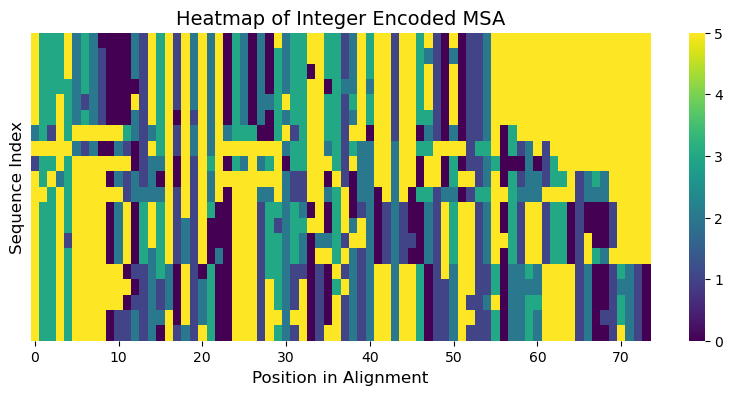

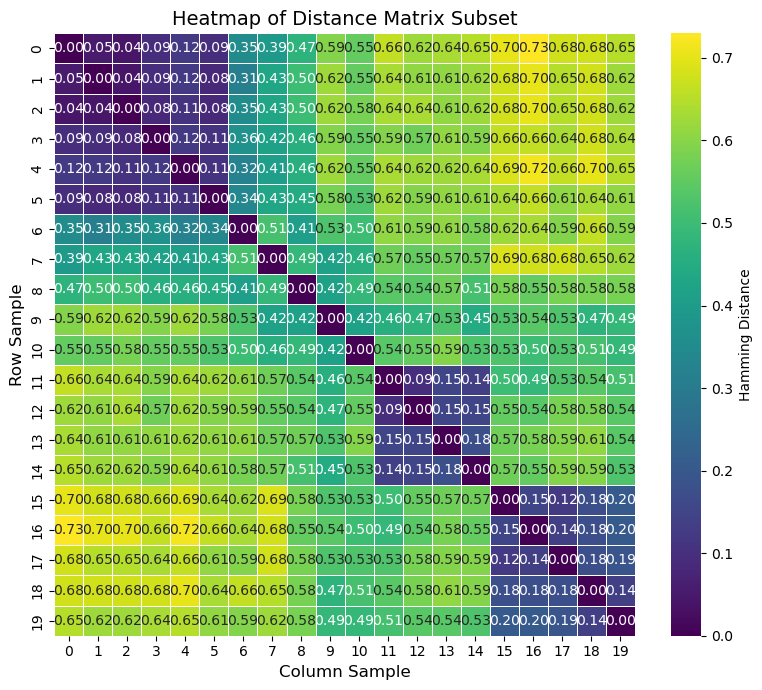

/Users/ogw/miniconda3/envs/plaslink/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/Users/ogw/miniconda3/envs/plaslink/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/Users/ogw/miniconda3/envs/plaslink/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


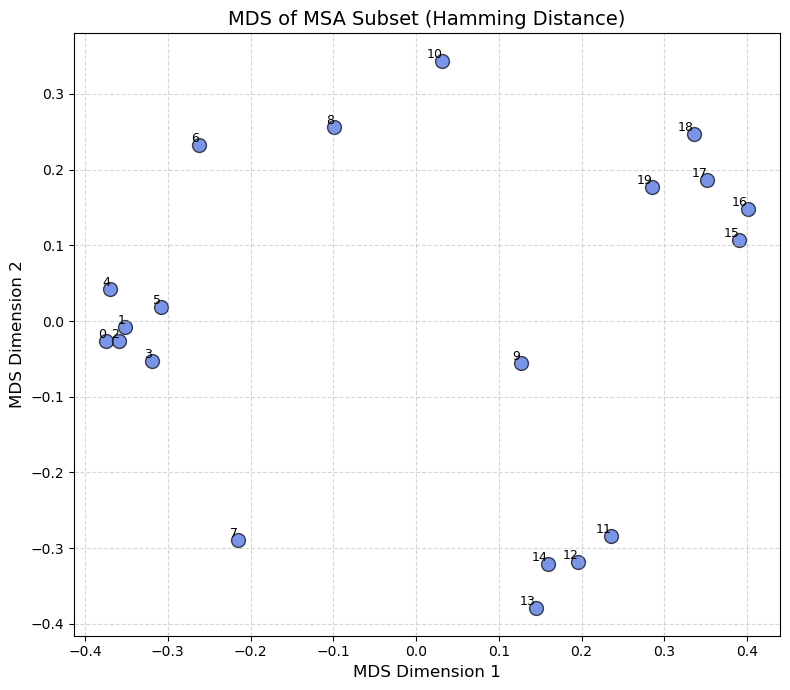

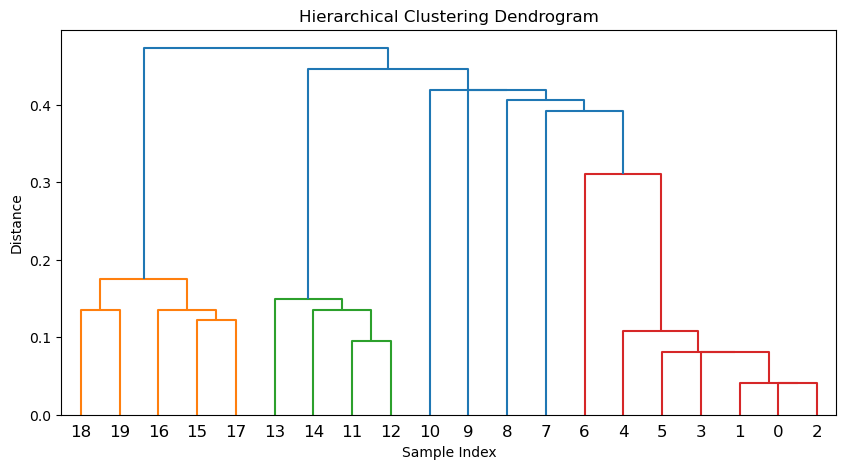

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0]


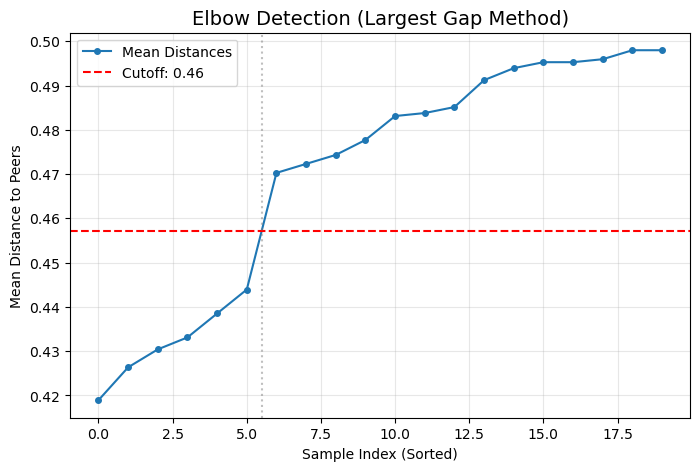

Split found at 0.4571. Detected 14 outliers.


NameError: name 'unique_labels' is not defined

In [93]:
# ==== PARAMS =====
from sklearn.manifold import MDS
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import MDS
import numpy as np
from sklearn.cluster import OPTICS
from sklearn.cluster import SpectralClustering
from scipy.linalg import eigh
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.cluster import AffinityPropagation
import numpy as np
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform
from sklearn.cluster import AgglomerativeClustering

verbose = 3
percentile_th = 5
expected_error_rate = 0.1
PLOTS = True

# ==== RUN =====

barcode_counts = df['Barcode'].value_counts()
all_barcodes = np.array(barcode_counts.index.tolist())

for i, (top_bc, count) in enumerate(barcode_counts.head(1).items()):

    print(f"\n\n=============\n{top_bc}")

    if verbose >= 1:
        print(f"Processing Top Barcode #{i+1}: {top_bc} (Count: {count})")

    top_bc = "TATTTATAGTCT" # Force specific barcode if needed for debug
    
    # RapidFuzz
    scores = process.cdist([top_bc], all_barcodes, scorer=fuzz.ratio, dtype=np.uint8)[0]
    candidate_bcs = all_barcodes[np.where(scores > 85)[0]]
    filtered_df = df[df['Barcode'].isin(candidate_bcs)].copy()

    # filtered_df = pd.read_csv("~/Downloads/fml.csv")

    if filtered_df.empty: continue

    if verbose >= 2:
        print(f"  > RapidFuzz gathered {len(filtered_df)} reads")

    result_df = recursive_hamming_driver(filtered_df, df, top_bc, 
                                          percentile_th=percentile_th, verbose=verbose, expected_error_rate=expected_error_rate)

    result_df2 = filter_result_df(result_df, top_bc, verbose)

    print(result_df2[['ID', 'cluster']])

In [53]:
result_df2

,ID,Barcode,Insert,cluster,cluster_consensus_bc,cluster_consensus_insert
285,58,TAGCCGCAATCA,GGGCCGCCTTATTTCCCGTGACCCTGTCAAGGCAGAGCGGTT,2,TAGCCGCAATCA,TGGCCGCCTTATTTCCCTTTACCCAGTCAAGGCGAGCGGT
286,58,CAGCCGCAATCA,TGGCCGCCTTATTTTCCCTTTTACCCACTCAAAGGCGAGCGGT,2,TAGCCGCAATCA,TGGCCGCCTTATTTCCCTTTACCCAGTCAAGGCGAGCGGT
287,58,TAGCCGCAATCA,TGGCCGCACTTATTTCCCTTTACCAGTCAAGGCGACGGT,2,TAGCCGCAATCA,TGGCCGCCTTATTTCCCTTTACCCAGTCAAGGCGAGCGGT
288,58,TAGCCACAATCA,TGGCCGCCTTTATTTCCCTATACCCAGGTCAAGGCGAGCGGT,2,TAGCCGCAATCA,TGGCCGCCTTATTTCCCTTTACCCAGTCAAGGCGAGCGGT
289,58,TAGCCGCAATC,GGCCGCTTATTTACCTTTACCCATTACAATGGCGAGCGGT,2,TAGCCGCAATCA,TGGCCGCCTTATTTCCCTTTACCCAGTCAAGGCGAGCGGT
290,58,TAGCCGCAACC,TGGCCTGCCATATCCCTTTACCCAGTCAACGCGAGGGT,2,TAGCCGCAATCA,TGGCCGCCTTATTTCCCTTTACCCAGTCAAGGCGAGCGGT
92265,20558,TAGCCGCAATCA,CTGTCCCGTATGGGTTCCTAAGGACACCACGTTATATTATGGCAGA...,0,TAGCCGCAATCA,CTGTCCCGTATGGGTTCCTAAGGACACCACAGTTATATTAGGCAGA...
92266,20558,TAGCCGCAATCA,CTGTCCCGTAGGGTTCCTAAGGCACCACAGGTATATTGGCAGAAAGT,0,TAGCCGCAATCA,CTGTCCCGTATGGGTTCCTAAGGACACCACAGTTATATTAGGCAGA...
92267,20558,TAGCCGCAATCAA,CTGTCCCGTATGGGTTCCTAAGGACACCAAATTTATATTAGGCAGA...,0,TAGCCGCAATCA,CTGTCCCGTATGGGTTCCTAAGGACACCACAGTTATATTAGGCAGA...
92268,20558,TAGCCGCAATCA,CTGTCCCGTATGGTTCCTGAGGACACCACAGTATATTAGGCAGAAAAT,0,TAGCCGCAATCA,CTGTCCCGTATGGGTTCCTAAGGACACCACAGTTATATTAGGCAGA...


In [598]:
# import pandas as pd
# import io

# data = """
#          ID        Barcode                                     Insert
# 1123    254   CCATTGCGAAAT     ATAGTGAGCGGCTCAAGCGTTGTATGGGAAGGTAGATG
# 1124    254   CAATTGCGAAAT    ATAGTGAGCGGCTCAAGCGGGTGTATTGGAAGGAAGATT
# 1125    254   CCATTGCGTAAT     ATAGTGAGCAGGCTCAGCCTGGGTATTGGAAGGAAATG
# 1126    254   CCATTGCGAAAT   ATACGTGAGCAGGCCAAGCGTGTGCATTGGAAGGAAGATG
# 1127    254   CCATTGCGAAAT    ATAGTGAGCAGGCTCAAAGCGTTGTATTAGAGGAAGATG
# 13670  3015  CCATTGCATGAAA  TTAATATTTAGGTTACCAACTTTCTACAGGGAGACGAGCGA
# 33410  7411    CATTTGGAAAT  AGAGGTTGAGAGGAGGGCTTAAACGGTACTCCCCCTGAAAC
# """

# # Use io.StringIO to treat the string as a file, and then
# # use pd.read_csv with a space delimiter to parse the data.
# # The 'index_col=0' argument tells pandas to use the first column (the row numbers
# # like 1123, 13670, etc.) as the DataFrame index.
# df = pd.read_csv(io.StringIO(data), sep='\s\s+', engine='python', index_col=0)

# print(df)

         ID        Barcode                                     Insert
1123    254   CCATTGCGAAAT     ATAGTGAGCGGCTCAAGCGTTGTATGGGAAGGTAGATG
1124    254   CAATTGCGAAAT    ATAGTGAGCGGCTCAAGCGGGTGTATTGGAAGGAAGATT
1125    254   CCATTGCGTAAT     ATAGTGAGCAGGCTCAGCCTGGGTATTGGAAGGAAATG
1126    254   CCATTGCGAAAT   ATACGTGAGCAGGCCAAGCGTGTGCATTGGAAGGAAGATG
1127    254   CCATTGCGAAAT    ATAGTGAGCAGGCTCAAAGCGTTGTATTAGAGGAAGATG
13670  3015  CCATTGCATGAAA  TTAATATTTAGGTTACCAACTTTCTACAGGGAGACGAGCGA
33410  7411    CATTTGGAAAT  AGAGGTTGAGAGGAGGGCTTAAACGGTACTCCCCCTGAAAC


--- Clustering Results (Labels Assigned) ---
Index: ['S1', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7']
K-Means (K=3): [2 0 0 0 0 1 1]
Agglomerative (K=3): [0 0 0 0 0 2 1]
DBSCAN (eps=1, min_s=3): [0 0 0 0 0 0 0]
HDBSCAN (min_c=2, min_s=1): [-1 -1 -1 -1 -1 -1 -1]


/Users/ogw/miniconda3/envs/plaslink/lib/python3.11/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


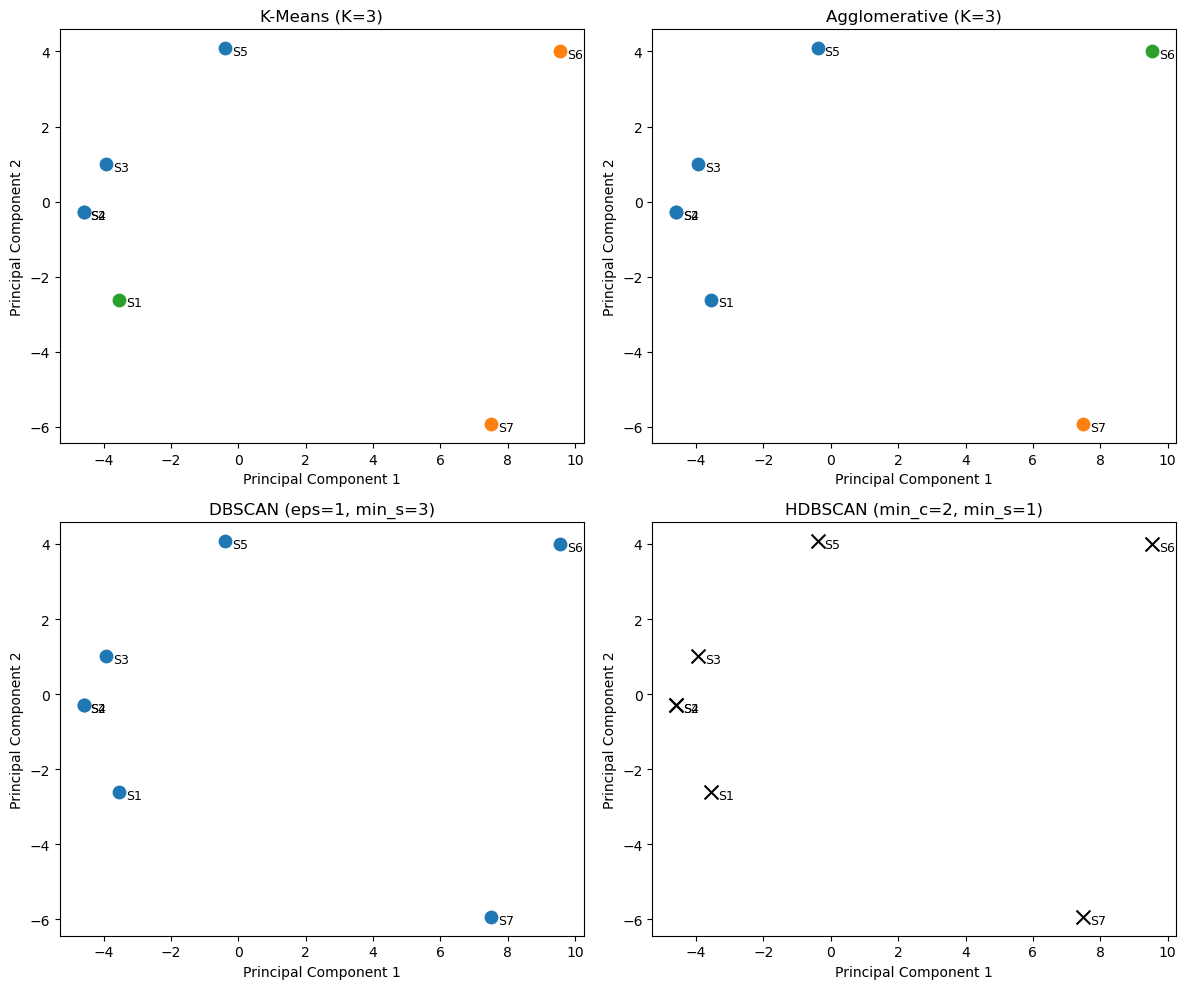

In [281]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, HDBSCAN
from sklearn.decomposition import PCA # Switched to PCA
from sklearn.metrics import pairwise_distances

# --- 1. Data Setup ---

# Your 7 inputs (sequences)
data = np.array([
    [3, 3, 2, 0, 3, 3, 0, 3, 1, 2, 0, 0, 1, 0, 0, 5, 5, 0, 1, 1, 3, 1, 1, 1, 3, 5, 5, 5], # S1
    [3, 2, 2, 0, 3, 0, 0, 3, 1, 5, 0, 3, 1, 0, 0, 5, 5, 0, 5, 1, 3, 1, 1, 1, 3, 5, 5, 5], # S2
    [3, 2, 2, 0, 3, 0, 0, 3, 1, 5, 0, 3, 1, 0, 0, 5, 5, 0, 5, 1, 3, 1, 5, 1, 3, 5, 5, 5], # S3
    [3, 2, 2, 0, 3, 0, 0, 3, 1, 5, 0, 3, 1, 0, 0, 5, 5, 0, 5, 1, 3, 1, 1, 1, 3, 5, 5, 5], # S4
    [0, 2, 2, 0, 3, 3, 0, 1, 2, 2, 1, 3, 1, 3, 2, 3, 3, 0, 5, 2, 0, 5, 5, 1, 5, 5, 5, 5], # S5
    [5, 5, 5, 5, 5, 1, 2, 1, 2, 2, 3, 3, 2, 2, 2, 3, 2, 2, 5, 0, 0, 5, 5, 5, 1, 2, 0, 0], # S6
    [0, 5, 5, 5, 5, 3, 3, 2, 1, 5, 0, 0, 2, 3, 3, 5, 5, 5, 2, 0, 0, 3, 3, 0, 1, 3, 3, 0]  # S7
], dtype=int)
sequence_names = [f'S{i+1}' for i in range(len(data))]
N_SEQUENCES = len(data)

# Calculate the Hamming distance matrix (still needed for distance-based clustering)
dist_matrix_subset = pairwise_distances(data, metric='hamming')

# --- 2. Dimensionality Reduction for Plotting (PCA) ---

# PCA must be run on the raw data, not the distance matrix
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(data) # Fit on the raw data!


# --- 3. Clustering Algorithms and Parameter Selection ---

K = 3

clustering_algorithms = {
    # K-Means: Uses raw data, implicitly using Euclidean distance (PCA's native distance)
    "K-Means (K=3)": KMeans(n_clusters=K, random_state=42, n_init='auto', max_iter=1000),

    # Agglomerative: Uses pre-computed Hamming distance
    "Agglomerative (K=3)": AgglomerativeClustering(n_clusters=K, linkage='complete', metric='precomputed'),

    # DBSCAN: Uses pre-computed Hamming distance
    "DBSCAN (eps=1, min_s=3)": DBSCAN(eps=1, min_samples=3, metric='precomputed'),

    # HDBSCAN: Uses pre-computed Hamming distance
    "HDBSCAN (min_c=2, min_s=1)": HDBSCAN(min_cluster_size=2, min_samples=1, metric='precomputed'),
}

# --- 4. Plotting Function ---

def plot_clustering_results(X_plot, labels, ax, title, sequence_names):
    """Plots the PCA results colored by cluster labels."""
    unique_labels = np.unique(labels)
    n_clusters = len(unique_labels)
    
    # Handle Noise (-1) specially
    has_noise = -1 in unique_labels
    
    # Plot Noise first
    if has_noise:
        noise_mask = labels == -1
        ax.scatter(X_plot[noise_mask, 0], X_plot[noise_mask, 1], 
                   label='Noise (-1)', color='black', marker='x', s=100, zorder=10)
    
    # Plot Clusters
    for i, lab in enumerate(unique_labels):
        if lab == -1: continue
        mask = labels == lab
        ax.scatter(X_plot[mask, 0], X_plot[mask, 1], label=f'Cluster {lab}', s=80)
        
    ax.set_title(title)
    ax.set_xlabel('Principal Component 1')
    ax.set_ylabel('Principal Component 2')
    
    # Annotate points with sequence names
    for i, txt in enumerate(sequence_names):
        ax.annotate(txt, (X_plot[i, 0], X_plot[i, 1]), 
                    textcoords="offset points", xytext=(5,-5), ha='left', fontsize=9)

# --- 5. Execute and Plot ---

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
plot_idx = 0

print("--- Clustering Results (Labels Assigned) ---")
print(f"Index: {sequence_names}")

for name, model in clustering_algorithms.items():
    # K-Means uses the raw data (Euclidean/default metric)
    if 'K-Means' in name:
        labels = model.fit_predict(data)
    
    # Others use the pre-computed Hamming distance matrix
    else:
        labels = model.fit_predict(dist_matrix_subset)

    # Plotting
    plot_clustering_results(X_pca, labels, axes[plot_idx], name, sequence_names)
    plot_idx += 1
    
    # Print Labels
    print(f"{name}: {labels}")

plt.tight_layout()
plt.show()
print("\n")

62.95
